In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Visualisation Données

In [258]:
arbres = pd.read_csv("train.csv", index_col = 'ID_ARBRE')
prev = pd.read_csv("prev.csv", index_col = 'ID_ARBRE')
benchmark = pd.read_csv("benchmark.csv", index_col = 'ID_ARBRE')

x = arbres[["type_sol", "classe_age", "classe_hauteur", "classe_circonference", "port_arbre", "vigueur_pousse", "plaie_collet", "fissure_tronc", "plaie_tronc", "fissure_houppier", "bois_mort_houppier", "plaie_houppier", "esperance_maintien"]]
x2 = prev[["type_sol", "classe_age", "classe_hauteur", "classe_circonference", "port_arbre", "vigueur_pousse", "plaie_collet", "fissure_tronc", "plaie_tronc", "fissure_houppier", "bois_mort_houppier", "plaie_houppier", "esperance_maintien"]]
y = arbres[["classification_diagnostic"]]

In [261]:
arbres.head(3)

,quartier,site,genre_arbre,situation,type_sol,surf_permeable,classe_age,hauteur,classe_hauteur,diametre,...,fissure_houppier,ecorce_incluse_houppier,bois_mort_houppier,plaie_houppier,observation_houppier,esperance_maintien,contrainte,classification_diagnostic,Long,Lat
ID_ARBRE,,,,,,,,,,,,,,,,,,,,,
0,Quartier 3 - Lycée International,RN13,Tilia,Alignement,MA,4.0,A,500,H1,31.830989,...,HPF,Non,HPBM,HPLS,0,1.0,Non,C1,2.064,48.900
1,Quartier 2 - Alsace - Pereire,Avenue du Maréchal Foch,Tilia,Alignement,MA,4.0,A,800,H2,76.394373,...,HFO,Non,HPBM,HPLNC,Fissure ouverte axe2 2M Sud Est,2.0,Oui,C4,2.085,48.903
2,Quartier 2 - Alsace - Pereire,RN13,Tilia,Alignement,GR,4.0,A,500,H1,38.197186,...,HPF,Non,HPBM,HPLS,0,1.0,Non,C1,2.070,48.899


In [262]:
benchmark.head()

,classification_diagnostic,Usage
ID_ARBRE,,
559,C2,Public
560,C2,Public
561,C2,Public
562,C2,Public
563,C2,Public


In [264]:
y.head()

,classification_diagnostic
ID_ARBRE,
0,C1
1,C4
2,C1
3,C2
4,C2


In [266]:
x.head(1)

,type_sol,classe_age,classe_hauteur,classe_circonference,port_arbre,vigueur_pousse,plaie_collet,fissure_tronc,plaie_tronc,fissure_houppier,bois_mort_houppier,plaie_houppier,esperance_maintien
ID_ARBRE,,,,,,,,,,,,,
0,MA,A,H1,C1,R5,P,RCPPL,TPF,TPLS,HPF,HPBM,HPLS,1.0


In [269]:
x2

,type_sol,classe_age,classe_hauteur,classe_circonference,port_arbre,vigueur_pousse,plaie_collet,fissure_tronc,plaie_tronc,fissure_houppier,bois_mort_houppier,plaie_houppier,esperance_maintien
ID_ARBRE,,,,,,,,,,,,,
559,MA,A,H2,C2,R5,P,RCPLS,TPF,TPLS,HPF,HPBM,HPLNC,2.0
560,Gr,JA,H2,C2,L,P,RCPPL,TPF,TPLS,HPF,HPBM,HPLS,1.0
561,MA,A,H2,C2,R5,P,RCPLS,TPF,TPLS,HPF,HPBM,HPLS,2.0
562,Gr,J,H1,C1,L,P,RCPPL,TPF,TPPL,HPF,HPBM,HPLS,1.0
563,S,A,H1,C3,A,P,RCPPL,TPF,TPLNC,HPF,HPBM,HPLNC,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
694,MA,A,H2,C3,R5,P,RCPLS,TPF,TPLS,HPF,HPBM,HPLS,2.0
695,MA,JA,H1,C2,SL,P,RCPPL,TPF,TPLS,HPF,HPBM,HPLNC,1.0
696,Gr,JA,H1,C2,SL,MP,RCPPL,TPF,TPLNC,HPF,HBMI,HPPL,1.0


## Entraînement - Calculs Probas - Classifieur de Bayes

In [272]:
def proba_xsy(X, tab_val, Y):
    x_colonnes = X.columns
    y_unique = np.unique(Y)
    pxsy = [np.prod([np.sum((X[col]==x_val) * (Y["classification_diagnostic"]==c)) / np.sum(Y["classification_diagnostic"]==c) for col, x_val in zip(x_colonnes, tab_val)]) for c in y_unique]
    return pxsy

In [274]:
def proba_xsy_lisse(X, tab_val, Y):
    x_colonnes = X.columns
    y_unique = np.unique(Y)
    alpha = 1
    pxsy = [np.prod([ (np.sum((X[col]==x_val) * (Y["classification_diagnostic"]==c)) + alpha) / (np.sum(Y["classification_diagnostic"]==c) + alpha*len(np.unique(X[col]))) for col, x_val in zip(x_colonnes, tab_val)]) for c in y_unique]
    return pxsy

In [276]:
proba_xsy_lisse(x, x.iloc[0], y)

[0.0035561345642920635,
 0.0008030952198810763,
 5.795182626183022e-05,
 2.223385715926233e-07,
 6.986020972034957e-08]

In [277]:
proba_xsy(x, x.iloc[0], y)

[0.004420002762215401, 0.0009044122989110241, 0.00015682693398043942, 0.0, 0.0]

In [205]:
def proba_y(Y):
    y_unique = np.unique(Y)
    return [np.sum(Y["classification_diagnostic"]==c)/len(Y) for c in y_unique]

In [209]:
def classifieur(X, tab_val, Y):
    y_unique = np.unique(Y)
    probas_ysx = [proba_xsy_lisse(X, tab_val, Y)[i] * proba_y(Y)[i] for i in range(len(y_unique))]
    return y_unique[np.argmax(probas_ysx)]

In [211]:
prediction = np.array([classifieur(x, x2.iloc[i], y) for i in range(len(x2))])

In [212]:
len(prediction)

137

In [222]:
def taux_erreur(predict, y):
    erreurs = len([i for i, j in zip(predict, y.to_numpy()) if i != j])
    taux = np.round((erreurs / len(y)) * 100, 5)
    print(f"Taux d'erreur : {taux}%")

In [254]:
taux_erreur(prediction, y)

Taux d'erreur : 14.33824%


In [226]:
def are(predict):
    erreurs = len([i for i, j in zip(predict, y.to_numpy().flatten()) if i == j])
    taux = np.round((erreurs / len(y)) * 100, 5)
    print(f"Average Classification Accuracy : {taux}%")

In [245]:
sub = pd.DataFrame({'classification_diagnostic': prediction})
sub.index.name = "ID_ARBRE"

In [247]:
id_arbre = x2.index  # Récupère l'index
print(id_arbre)  # Vérifie les valeurs

Index([559, 560, 561, 562, 563, 564, 565, 566, 567, 568,
       ...
       689, 690, 691, 692, 693, 694, 695, 696, 697, 698],
      dtype='int64', name='ID_ARBRE', length=137)


In [249]:
sub["ID_ARBRE"] = id_arbre  # Ajoute l'index comme colonne
sub = sub.set_index("ID_ARBRE")  # Le définit comme index

In [251]:
sub.head()

,classification_diagnostic
ID_ARBRE,
559,C2
560,C2
561,C2
562,C1
563,C4


In [242]:
#sub.to_csv("submition6.csv")

In [331]:
def matrice_confusion():
    # On a stack le vecteur des prédictions ŷ (à gauche) avec le vecteur des vraies valeurs y (à droite).
    stack_predict_et_y = np.vstack((prediction, y["classification_diagnostic"])).T
    classes_y = np.unique(y)
    confusion_matrix = np.zeros((len(classes_y), len(classes_y)), dtype = int)
    for i, c1 in enumerate(classes_y):
        for j, c2 in enumerate(classes_y):
            confusion_matrix[i][j] = np.sum((stack_predict_et_y[:, 0]==c2) & (stack_predict_et_y[:, 1]==c1))
    #res = np.hstack((confusion_matrix, classes_y))
    return confusion_matrix

matrice_confusion()

array([[138,  47,   0,   0,   0],
       [ 58, 248,   5,   1,   3],
       [  1,  13,  15,   2,   0],
       [  0,   0,   2,   5,   0],
       [  1,   0,   1,   1,   3]])

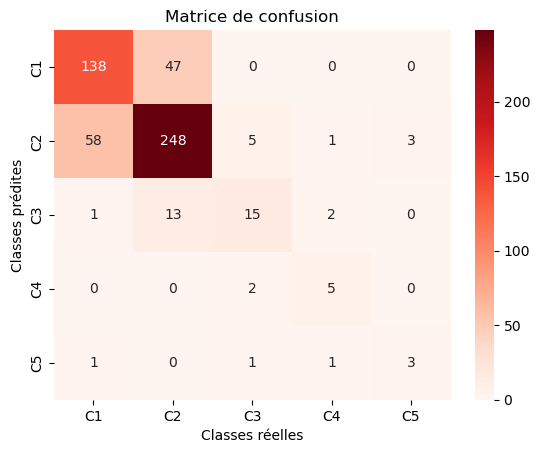

In [333]:
sns.heatmap(matrice_confusion(), annot=True, fmt="d", xticklabels=np.unique(y), yticklabels=np.unique(y), cmap="Reds")
plt.xlabel("Classes réelles")
plt.ylabel("Classes prédites")
plt.title("Matrice de confusion")
plt.show()